# Embeddings & Vector Similarity
**Topics covered:** What embeddings are · vector representations · sentence transformers · embedding creation  
Cosine similarity · distance metrics · similarity search · retrieval basics

In [ ]:
# Install if not already present
# !pip install sentence-transformers

---
## PART 1 — What Are Embeddings?

### The Core Idea

An **embedding** converts a piece of content (word, sentence, image, user profile) into a **fixed-size list of numbers** — a vector — such that *similar things end up near each other* in that numeric space.

**Real-world analogy:** Imagine every city on Earth gets GPS coordinates (lat, lon). You didn't describe London with words — you described it with two numbers. Now you can calculate which cities are close, cluster them, sort them by distance.  
Embeddings do the same thing for meaning. "King" and "Queen" end up near each other. "Python" (the language) and "Java" end up near each other — far from "Python" (the snake).

### Why Does This Matter for AI Engineering?

| Task | How embeddings help |
|---|---|
| Semantic search | Find docs that *mean* the same thing, not just share keywords |
| RAG systems | Retrieve the right context chunks for an LLM |
| Recommendations | Users/items with similar embeddings get recommended to each other |
| Clustering | Group documents by topic without any labels |

---
## PART 2 — Vectors From Scratch

Before using a model, let's build intuition with hand-crafted vectors.

In [1]:
import numpy as np

# Hand-crafted 3D embedding space:
# [is_animal, is_royalty, is_male]
king   = np.array([0.0, 1.0, 1.0])
queen  = np.array([0.0, 1.0, 0.0])
man    = np.array([0.0, 0.0, 1.0])
woman  = np.array([0.0, 0.0, 0.0])
dog    = np.array([1.0, 0.0, 1.0])

# The famous word2vec relationship: king - man + woman ≈ queen
result = king - man + woman
print("king - man + woman =", result)
print("queen               =", queen)
print("Are they the same? ", np.allclose(result, queen))

king - man + woman = [0. 1. 0.]
queen               = [0. 1. 0.]
Are they the same?  True


**What just happened?** Embedding arithmetic works because meaning is encoded geometrically. Real embedding models (with 384–1536 dimensions) learn these relationships automatically from billions of text examples.

---
## PART 3 — Sentence Transformers

## sentence-transformers

`sentence-transformers` is both a library and a collection of pre-trained models.

---

### The Library

```bash
pip install sentence-transformers
```

Built on top of HuggingFace `transformers` — it simplifies the process of encoding sentences into vectors. Without it you'd write ~20 lines of tokenization + model forward pass + pooling. With it:

```python
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('all-MiniLM-L6-v2')
vector = model.encode("The dog ran fast")
```

Three lines.

---

### The Pre-trained Models

The models themselves live on HuggingFace Hub. Writing `'all-MiniLM-L6-v2'` downloads that specific model (~90MB) and caches it locally — no training involved, just using a model someone already trained on hundreds of millions of sentence pairs.

| Model | Dimensions | Size | Good for |
|-------|-----------|------|----------|
| `all-MiniLM-L6-v2` | 384 | 90MB | Fast, general purpose |
| `all-mpnet-base-v2` | 768 | 420MB | Better quality, slower |
| `multi-qa-MiniLM-L6-cos-v1` | 384 | 90MB | Question-answer retrieval |

> `SentenceTransformer('all-MiniLM-L6-v2')` = use the library to load a pre-trained model from HuggingFace.

In [2]:
from sentence_transformers import SentenceTransformer

# Downloads ~90MB on first run, cached after
model = SentenceTransformer('all-MiniLM-L6-v2')
print("Model loaded")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model loaded


In [3]:
# Single sentence → embedding
sentence = "Machine learning is a subset of artificial intelligence."
embedding = model.encode(sentence)

print(f"Input:          '{sentence}'")
print(f"Output type:    {type(embedding)}")
print(f"Output shape:   {embedding.shape}")
print(f"First 5 values: {embedding[:5].round(4)}")
print(f"Last  5 values: {embedding[-5:].round(4)}")

Input:          'Machine learning is a subset of artificial intelligence.'
Output type:    <class 'numpy.ndarray'>
Output shape:   (384,)
First 5 values: [-0.0235 -0.0106  0.0719  0.0304  0.0286]
Last  5 values: [ 0.0526  0.0378  0.0604  0.0795 -0.0471]


In [4]:
# Batch encoding (more efficient than a loop)
sentences = [
    "Python is a popular programming language.",
    "I love hiking in the mountains.",
    "Deep learning uses neural networks.",
    "The cat sat on the mat.",
    "AI engineers build intelligent systems.",
]

embeddings = model.encode(sentences)  # returns (5, 384) array
print(f"Batch shape: {embeddings.shape}")
print(f"Each row is one sentence's embedding (384 floats)")

Batch shape: (5, 384)
Each row is one sentence's embedding (384 floats)


## Sentence Embeddings — Fixed Size Regardless of Length

A whole sentence gets compressed into **one single 384-dimensional vector**, no matter how long the sentence is.

```python
sentences = [
    "Python is a popular programming language.",
    "I love hiking in the mountains.",
    "Deep learning uses neural networks.",
]

embeddings = model.encode(sentences)
embeddings.shape  # (3, 384) — 3 sentences, each a 384-dim vector
```

```python
short = model.encode("Hi")
long  = model.encode("Machine learning is a branch of AI that enables systems to learn from data.")

short.shape  # (384,)
long.shape   # (384,)  ← same size despite being much longer
```

---

### How It Compresses a Sentence into 384 Numbers

The transformer reads all words together, then **pools** them into one vector.

```
"Deep learning uses neural networks"
        ↓
  [deep]  [learning]  [uses]  [neural]  [networks]   ← each word gets a temp vector
        ↓
   average/pool all word vectors together
        ↓
        (384,)   ← one vector representing the whole sentence's meaning
```

The pooling step is what collapses many word vectors into one sentence vector. The 384 numbers capture overall **meaning**, not individual words.

---

### Want Per-Word Vectors Instead?

Use BERT directly (not sentence-transformers) — it returns `(num_words, 768)`, one vector per word.

Sentence-transformers adds the pooling step on top specifically to give you **one vector per sentence**.

---
## PART 4 — Cosine Similarity

### Why Not Euclidean Distance?

Euclidean distance measures absolute gap in space. The problem: a sentence with 100 words produces a longer vector magnitude than a 5-word sentence, even if they mean the same thing.  

**Cosine similarity** measures the *angle* between vectors, ignoring magnitude.  
Range: **−1** (opposite meanings) → **0** (unrelated) → **+1** (identical meaning)

$$\text{cos\_sim}(A, B) = \frac{A \cdot B}{\|A\| \|B\|}$$

In [5]:
def cosine_similarity(a: np.ndarray, b: np.ndarray) -> float:
    """Cosine similarity from scratch."""
    dot_product = np.dot(a, b)
    norm_a = np.linalg.norm(a)
    norm_b = np.linalg.norm(b)
    return dot_product / (norm_a * norm_b)


# Verify with toy vectors
identical = np.array([1.0, 2.0, 3.0])
similar   = np.array([2.0, 4.0, 6.0])   # same direction, different magnitude
opposite  = np.array([-1.0, -2.0, -3.0])
unrelated = np.array([1.0, 0.0, 0.0])

print(f"Identical direction:  {cosine_similarity(identical, identical):.4f}  (expect 1.0)")
print(f"Same direction, 2×:   {cosine_similarity(identical, similar):.4f}  (expect 1.0, magnitude ignored)")
print(f"Opposite direction:   {cosine_similarity(identical, opposite):.4f}  (expect -1.0)")
print(f"Unrelated:            {cosine_similarity(identical, unrelated):.4f}")

Identical direction:  1.0000  (expect 1.0)
Same direction, 2×:   1.0000  (expect 1.0, magnitude ignored)
Opposite direction:   -1.0000  (expect -1.0)
Unrelated:            0.2673


In [7]:
# Now with real sentence embeddings
test_pairs = [
    ("The dog ran across the field.",  "A puppy sprinted through the grass."),
    ("The dog ran across the field.",  "I enjoy eating sushi."),
    ("Neural networks learn features.", "Deep learning extracts representations."),
    ("The stock market crashed today.", "Investors lost money on Wall Street."),
    ("How do I cook pasta?",            "What is the best recipe for spaghetti?"),
]

print(f"{'Pair':<5} {'Score':>6}  Sentence A  →  Sentence B")
print("-" * 80)
for i, (a, b) in enumerate(test_pairs, 1):
    emb_a = model.encode(a)
    emb_b = model.encode(b)
    score = cosine_similarity(emb_a, emb_b)
    print(f"{i:<5} {score:>6.3f}  '{a}'  →  '{b}'")


Pair   Score  Sentence A  →  Sentence B
--------------------------------------------------------------------------------
1      0.583  'The dog ran across the field.'  →  'A puppy sprinted through the grass.'
2     -0.056  'The dog ran across the field.'  →  'I enjoy eating sushi.'
3      0.386  'Neural networks learn features.'  →  'Deep learning extracts representations.'
4      0.583  'The stock market crashed today.'  →  'Investors lost money on Wall Street.'
5      0.702  'How do I cook pasta?'  →  'What is the best recipe for spaghetti?'


---
## PART 5 — Distance Metrics Compared

| Metric | Formula | Good for | Range |
|---|---|---|---|
| **Cosine similarity** | angle between vectors | text, high-dim embeddings | −1 to 1 |
| **Euclidean distance** | straight-line distance | low-dim, normalized data | 0 to ∞ |
| **Dot product** | A·B (no normalization) | when magnitude matters (reranking) | −∞ to ∞ |
| **Manhattan (L1)** | sum of absolute diffs | sparse features | 0 to ∞ |

In [8]:

def euclidean_distance(a: np.ndarray, b: np.ndarray) -> float:
    return float(np.linalg.norm(a - b))

def dot_product(a: np.ndarray, b: np.ndarray) -> float:
    return float(np.dot(a, b))

def manhattan_distance(a: np.ndarray, b: np.ndarray) -> float:
    return float(np.sum(np.abs(a - b)))


# Compare metrics on a semantically close vs unrelated pair
query    = "How does machine learning work?"
close    = "What is the process behind training an ML model?"
far      = "The Eiffel Tower is in Paris."

q_emb = model.encode(query)
c_emb = model.encode(close)
f_emb = model.encode(far)

print(f"{'Metric':<25} {'Close pair':>12} {'Far pair':>12}  (closer = more similar)")
print("-" * 60)
print(f"{'Cosine similarity':<25} {cosine_similarity(q_emb, c_emb):>12.4f} {cosine_similarity(q_emb, f_emb):>12.4f}  (higher = closer)")
print(f"{'Euclidean distance':<25} {euclidean_distance(q_emb, c_emb):>12.4f} {euclidean_distance(q_emb, f_emb):>12.4f}  (lower = closer)")
print(f"{'Dot product':<25} {dot_product(q_emb, c_emb):>12.4f} {dot_product(q_emb, f_emb):>12.4f}  (higher = closer)")
print(f"{'Manhattan distance':<25} {manhattan_distance(q_emb, c_emb):>12.4f} {manhattan_distance(q_emb, f_emb):>12.4f}  (lower = closer)")

Metric                      Close pair     Far pair  (closer = more similar)
------------------------------------------------------------
Cosine similarity               0.6701      -0.0053  (higher = closer)
Euclidean distance              0.8123       1.4180  (lower = closer)
Dot product                     0.6701      -0.0053  (higher = closer)
Manhattan distance             12.9717      21.9996  (lower = closer)


---
## PART 6 — Similarity Search

Similarity search = given a **query**, find the **top-k most similar items** from a corpus.  
This is the core operation in every RAG system and semantic search engine.

The brute-force approach: compute query vs. every document, sort by score. Works fine for small corpora (<10k docs). At scale you'd use FAISS or Chroma.

In [9]:
# A small document corpus
corpus = [
    "Python is widely used for machine learning and data science.",
    "The Great Wall of China is one of the Seven Wonders.",
    "Neural networks are inspired by biological neurons in the brain.",
    "The Amazon rainforest produces 20% of the world's oxygen.",
    "Gradient descent optimizes model parameters during training.",
    "Mount Everest is the tallest mountain on Earth.",
    "Transformers use self-attention to model long-range dependencies.",
    "The Pacific Ocean is the largest ocean on the planet.",
    "Overfitting occurs when a model memorizes training data.",
    "Rome was not built in a day.",
    "Embeddings convert text into dense numeric vectors.",
    "Climate change is causing global temperatures to rise.",
]

# Pre-compute all corpus embeddings once (expensive, do it once)
corpus_embeddings = model.encode(corpus)
print(f"Corpus embeddings shape: {corpus_embeddings.shape}")

Corpus embeddings shape: (12, 384)


In [10]:
def semantic_search(query: str, corpus: list[str], corpus_embeddings: np.ndarray, top_k: int = 3) -> list[dict]:
    # Step 1: convert query sentence into a 384-dim vector
    query_embedding = model.encode(query)  # shape: (384,)

    # Step 2: normalize query to unit vector (length = 1)
    # so that dot product later gives cosine similarity, not raw dot product
    query_norm = query_embedding / np.linalg.norm(query_embedding)  # shape: (384,)

    # Step 3: normalize every corpus doc to unit vector
    # axis=1 computes norm per row (per doc), keepdims keeps shape (n,1) for broadcasting
    # without keepdims shape would be (n,) and division would fail
    corpus_norm = corpus_embeddings / np.linalg.norm(corpus_embeddings, axis=1, keepdims=True)  # shape: (n_docs, 384)

    # Step 4: matrix multiply → cosine similarity of query vs ALL docs in one shot
    # (n_docs, 384) @ (384,) → (n_docs,)  — one score per document
    # faster than looping and calling cosine_similarity() n times
    scores = corpus_norm @ query_norm    # matrix multiplication

    # Step 5: argsort returns indices sorted ascending, [::-1] reverses to descending
    # [:top_k] takes only the top k indices
    top_indices = np.argsort(scores)[::-1][:top_k]

    # Step 6: i is rank position (0,1,2), idx is the actual index in corpus
    return [
        {"rank": i + 1, "score": float(scores[idx]), "doc": corpus[idx]}
        for i, idx in enumerate(top_indices)
    ]



# Try it
queries = [
    "How does a machine learning model learn?",
    "What is the largest ocean?",
    "Tell me about natural language processing.",
]

for query in queries:
    results = semantic_search(query, corpus, corpus_embeddings, top_k=3)
    print(f"\nQuery: '{query}'")
    for r in results:
        print(f"  [{r['rank']}] {r['score']:.4f}  {r['doc']}")


Query: 'How does a machine learning model learn?'
  [1] 0.4917  Overfitting occurs when a model memorizes training data.
  [2] 0.4747  Gradient descent optimizes model parameters during training.
  [3] 0.3488  Neural networks are inspired by biological neurons in the brain.

Query: 'What is the largest ocean?'
  [1] 0.7907  The Pacific Ocean is the largest ocean on the planet.
  [2] 0.3187  Mount Everest is the tallest mountain on Earth.
  [3] 0.2371  The Amazon rainforest produces 20% of the world's oxygen.

Query: 'Tell me about natural language processing.'
  [1] 0.2682  Python is widely used for machine learning and data science.
  [2] 0.2507  Embeddings convert text into dense numeric vectors.
  [3] 0.2042  Overfitting occurs when a model memorizes training data.


```
query → encode → (384,) → normalize → (384,)
                                           ↓
corpus → encode → (12,384) → normalize → (12,384)
                                           ↓
                              (12,384) @ (384,) = (12,) scores
                                           ↓
                                      argsort → top 3 indices
                                           ↓
                                      return ranked docs
```

---
## PART 7 — Retrieval Basics: Building a Mini Search Engine

Let's wire everything together into a reusable class — this is essentially what a vector store does internally.

In [11]:
class SimpleVectorStore:
    """Minimal in-memory vector store. Foundation for RAG retrieval."""

    def __init__(self, model: SentenceTransformer):
        self.model = model                         # sentence transformer used to encode text into vectors
        self.documents: list[dict] = []            # each entry: {text, metadata, embedding} for one document
        self._embeddings: np.ndarray | None = None # (n_docs, 384) matrix — built once docs are added, used for fast search

    def add_documents(self, texts: list[str], metadata: list[dict] | None = None) -> None:
        # if caller didn't pass metadata, create an empty dict for each text
        if metadata is None:
            metadata = [{} for _ in texts]

        # encode all texts in one batch → (n_docs, 384)
        # batch is faster than encoding one by one in a loop
        embeddings = self.model.encode(texts)

        # pair each text with its metadata and embedding, store together as one dict
        for text, meta, emb in zip(texts, metadata, embeddings):
            self.documents.append({"text": text, "metadata": meta, "embedding": emb})

        # rebuild the embeddings matrix after every add
        # np.stack pulls the embedding array from each doc and stacks into (n_docs, 384)
        # kept separate from self.documents for fast matrix multiply during search
        self._embeddings = np.stack([d["embedding"] for d in self.documents])

        print(f"Store now has {len(self.documents)} documents")

    def search(self, query: str, top_k: int = 3) -> list[dict]:
        # nothing to search if store is empty
        if not self.documents:
            return []

        # encode query into a 384-dim vector
        q_emb = self.model.encode(query)

        # normalize query to unit vector so dot product = cosine similarity
        q_norm = q_emb / np.linalg.norm(q_emb)

        # normalize every doc vector to unit length (per row)
        c_norm = self._embeddings / np.linalg.norm(self._embeddings, axis=1, keepdims=True)

        # (n_docs, 384) @ (384,) → (n_docs,)
        # computes cosine similarity of query against every doc in one matrix multiply
        scores = c_norm @ q_norm

        # argsort returns indices sorted ascending → reverse → take top k
        top_idx = np.argsort(scores)[::-1][:top_k]

        # return ranked results — i is the corpus index, scores[i] is its similarity score
        return [
            {"score": float(scores[i]), "text": self.documents[i]["text"], "metadata": self.documents[i]["metadata"]}
            for i in top_idx
        ]

    def __len__(self) -> int:
        # allows len(store) to return number of stored documents
        return len(self.documents)


store = SimpleVectorStore(model)

# each doc is a tuple: (text, metadata dict)
docs = [
    ("RAG combines retrieval with generation to reduce LLM hallucinations.", {"topic": "rag"}),
    ("Vector databases store embeddings and support fast nearest-neighbor search.", {"topic": "vector_db"}),
    ("Fine-tuning adapts a pretrained model to a specific task using labeled data.", {"topic": "finetuning"}),
    ("Prompt engineering shapes LLM behavior without changing model weights.", {"topic": "prompting"}),
    ("Chunking splits long documents into smaller pieces before embedding.", {"topic": "rag"}),
    ("FAISS is a library by Meta for efficient similarity search at scale.", {"topic": "vector_db"}),
    ("LLMs are pretrained on large text corpora using next-token prediction.", {"topic": "llm"}),
    ("Agents use LLMs to plan and execute multi-step tasks using tools.", {"topic": "agents"}),
]

# zip(*docs) transposes list of tuples → two separate tuples
# [("t1",m1), ("t2",m2)] becomes ("t1","t2") and (m1,m2)
texts, metas = zip(*docs)

store.add_documents(list(texts), list(metas))


Store now has 8 documents


In [12]:
# Query the store
test_queries = [
    "How do I reduce hallucinations from ChatGPT?",
    "What tool should I use for fast vector search?",
    "How do AI systems remember context and use tools?",
]

for q in test_queries:
    print(f"\nQuery: '{q}'")
    for r in store.search(q, top_k=2):
        print(f"  [{r['score']:.3f}] [{r['metadata']['topic']:>10}]  {r['text']}")


Query: 'How do I reduce hallucinations from ChatGPT?'
  [0.523] [       rag]  RAG combines retrieval with generation to reduce LLM hallucinations.
  [0.050] [       llm]  LLMs are pretrained on large text corpora using next-token prediction.

Query: 'What tool should I use for fast vector search?'
  [0.624] [ vector_db]  Vector databases store embeddings and support fast nearest-neighbor search.
  [0.456] [ vector_db]  FAISS is a library by Meta for efficient similarity search at scale.

Query: 'How do AI systems remember context and use tools?'
  [0.460] [    agents]  Agents use LLMs to plan and execute multi-step tasks using tools.
  [0.432] [finetuning]  Fine-tuning adapts a pretrained model to a specific task using labeled data.


---
## PART 8 — Embedding Space Visualization (Bonus)

Use PCA (Principal Component Analysis) to project 384-dim embeddings down to 2D so we can see clusters.

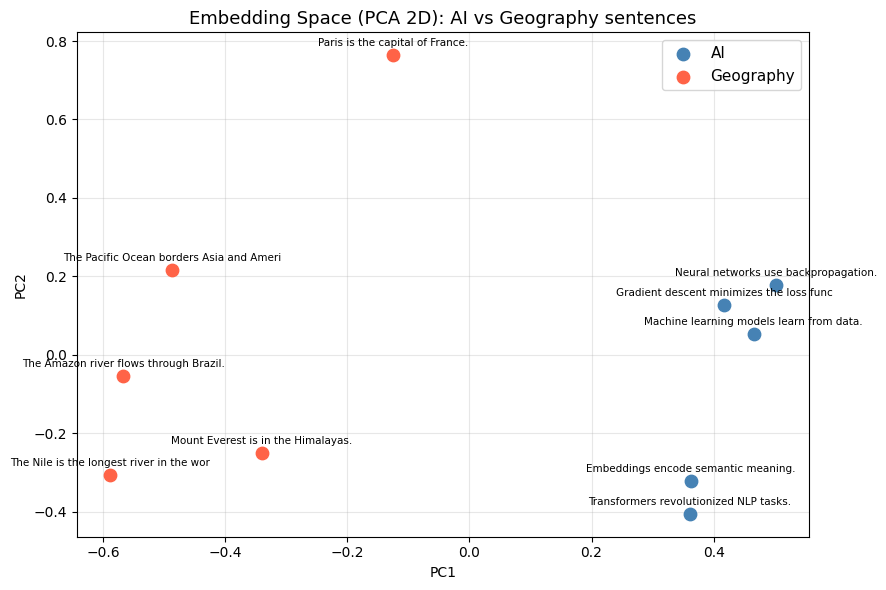

In [13]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Sentences from two clear topics: AI and Geography
labeled_sentences = [
    ("Machine learning models learn from data.",       "AI"),
    ("Neural networks use backpropagation.",           "AI"),
    ("Gradient descent minimizes the loss function.",  "AI"),
    ("Transformers revolutionized NLP tasks.",         "AI"),
    ("Embeddings encode semantic meaning.",            "AI"),
    ("The Amazon river flows through Brazil.",         "Geography"),
    ("Mount Everest is in the Himalayas.",             "Geography"),
    ("The Nile is the longest river in the world.",    "Geography"),
    ("Paris is the capital of France.",               "Geography"),
    ("The Pacific Ocean borders Asia and America.",    "Geography"),
]

sentences, labels = zip(*labeled_sentences)
embs = model.encode(list(sentences))

coords = PCA(n_components=2).fit_transform(embs)

colors = {"AI": "steelblue", "Geography": "tomato"}
fig, ax = plt.subplots(figsize=(9, 6))
for i, (x, y) in enumerate(coords):
    label = labels[i]
    ax.scatter(x, y, color=colors[label], s=80, zorder=3)
    ax.annotate(sentences[i][:40], (x, y), fontsize=7.5, ha="center", va="bottom", xytext=(0, 5), textcoords="offset points")

# Legend
for name, color in colors.items():
    ax.scatter([], [], color=color, label=name, s=80)
ax.legend(fontsize=11)
ax.set_title("Embedding Space (PCA 2D): AI vs Geography sentences", fontsize=13)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## Key Takeaways

| Concept | What to remember |
|---|---|
| **Embedding** | Fixed-size vector; similar meaning → nearby vectors |
| **Sentence Transformers** | Pre-trained models for high-quality sentence embeddings; `all-MiniLM-L6-v2` is a solid default |
| **Cosine similarity** | Measures angle, ignores magnitude — best metric for text embeddings |
| **Euclidean distance** | Magnitude-sensitive; worse for high-dim text, useful for normalized low-dim data |
| **Similarity search** | Encode query → compare to corpus → return top-k by score |
| **SimpleVectorStore** | The pattern you'll see in FAISS, ChromaDB, Pinecone — just at scale |
